## Dataset
We will use Amazon US reviews for **Musical Instruments** (tab-separated, gzip-compressed).

Dataset links (copy/paste):
- TSV.GZ:
  https://mcauleylab.ucsd.edu/public_datasets/pml_data/amazon_reviews_us_Musical_Instruments_v1_00.tsv.gz
- Amazon Reviews PDS TSV index (original source listing):
  https://s3.amazonaws.com/amazon-reviews-pds/tsv/index.txt

**Important:** The dataset is large. You can load it completely or just a manageable subset (e.g., first `MAX_REVIEWS` rows) or implement streaming + sampling.


In [20]:
# =========================================================
# SETUP (run this cell first)
# =========================================================
import os
import gzip
import math
import random
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 256
random.seed(SEED)
np.random.seed(SEED)

print("Ready.")

Ready.


## Part 1 — Download + Load Data

**Task:** Download the dataset if needed, then load a subset into a DataFrame.

**Requirements:**
- Use `MAX_REVIEWS` to cap rows (recommended 50k–300k depending on Colab memory).
- Keep only the columns you need for CF and EDA.
- Convert `star_rating` to integer.
- Parse `review_date` as datetime (needed if you do a time-based split).

**Deliverable:** A DataFrame `df` with at least:
- `customer_id`, `product_id`, `star_rating`, `review_date`, `product_title`

**Question (short):**
1. Why might time-based splitting be preferable to random splitting for recommender evaluation?
<br><br>Popular opinion changes overtime. What was popular with certain groups a user is apart of can change. If we used random split we could treat outdated reviews as relevant for predicting a user's review for an instrument. Splitting by time can help us avoid this.

In [21]:
# =========================================================
# DATA DOWNLOAD
# =========================================================
DATA_DIR = "/home/anthony/repos/cmpe256/data/raw"
os.makedirs(DATA_DIR, exist_ok=True)

DATA_URL = "https://mcauleylab.ucsd.edu/public_datasets/pml_data/amazon_reviews_us_Musical_Instruments_v1_00.tsv.gz"
DATA_PATH = os.path.join(DATA_DIR, "amazon_reviews_us_Musical_Instruments_v1_00.tsv.gz")

if not os.path.exists(DATA_PATH):
    print("Downloading dataset...")
    import urllib.request
    urllib.request.urlretrieve(DATA_URL, DATA_PATH)
    print("Download complete:", DATA_PATH)
else:
    print("Dataset already exists:", DATA_PATH)

Dataset already exists: /home/anthony/repos/cmpe256/data/raw/amazon_reviews_us_Musical_Instruments_v1_00.tsv.gz


In [22]:
# =========================================================
# LOAD SUBSET
# =========================================================
MAX_REVIEWS = 150_000  # TODO: adjust if needed

USECOLS = ["customer_id", "product_id", "star_rating", "review_date", "product_title"]

df = pd.read_csv(
    DATA_PATH,
    sep="\t",
    compression="gzip",
    usecols=USECOLS,
    nrows=MAX_REVIEWS,
)

# Basic cleaning
df = df.dropna(subset=["customer_id", "product_id", "star_rating"])
df["star_rating"] = df["star_rating"].astype(int)
df["review_date"] = pd.to_datetime(df["review_date"], errors="coerce")
df = df.dropna(subset=["review_date"])

df.head(50)

,customer_id,product_id,product_title,star_rating,review_date
0,45610553,B00HH62VB6,AGPtek® 10 Isolated Output 9V 12V 18V Guitar P...,3,2015-08-31
1,14640079,B003LRN53I,Sennheiser HD203 Closed-Back DJ Headphones,5,2015-08-31
2,6111003,B0006VMBHI,AudioQuest LP record clean brush,3,2015-08-31
3,1546619,B002B55TRG,Hohner Inc. 560BX-BF Special Twenty Harmonica,5,2015-08-31
4,12222213,B00N1YPXW2,Blue Yeti USB Microphone - Blackout Edition,5,2015-08-31
5,46018513,B001N4GRGS,Middle Atlantic Products QFAN-119,5,2015-08-31
6,10225065,B009PJRMHQ,Kmise 1pc Pickguard for Gibson Sg Standard 3-p...,2,2015-08-31
7,6356995,B00NKBDAZS,Kealoha Concert Ukulele - Stunning NEW Printed...,5,2015-08-31
8,35297198,B006MIU7U2,Halco 80000 - MR16/3WW/FL/LED2 MR16 Flood LED ...,5,2015-08-31
9,32139520,B000FIBD0I,Gator GPTBLACK Plywood Pedal Board with Black ...,5,2015-08-31


## Part 2 — Exploratory Data Analysis (EDA)

**Task:** Create at least **3 plots** and **3–6 written observations** covering:

Required EDA items:
1. Rating distribution (histogram or bar chart).
2. Reviews per user distribution (include mean/median; consider log-scale).
3. Reviews per item distribution (include mean/median; consider log-scale).

Optional but recommended:
- Sparsity estimate (density of the user–item matrix)
- Top-10 most-reviewed items (show titles)
- Do you see “long tail” behavior?

**Deliverable:** Plots + short written interpretation.

**Questions:**
1. Is the dataset sparse? Provide a quantitative estimate.<br><br>
The data is sparsed with a sparsity estimate of 0.999 so it very sparsed. Each user reviews an average of 1-2 instruments.<br><br>
2. What bias might exist in this dataset (e.g., rating inflation, selection bias)?<br><br>
There's possibly inflationay bias most of the star rating are "5" meaning that there is a high chance that our recommender system will predict higher rating based on users mainly rating 5 stars on most items.

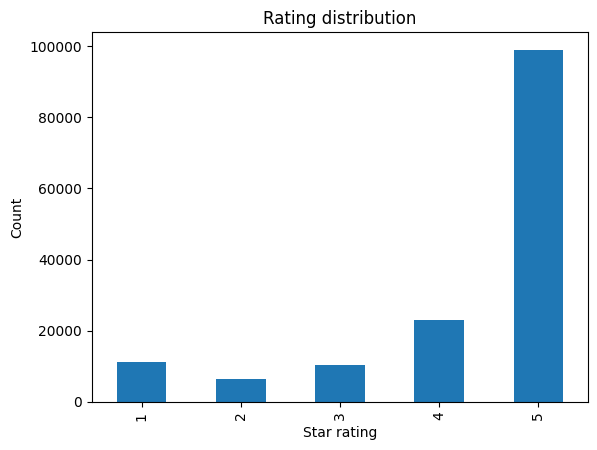

In [23]:
# =========================================================
# EDA 1 — Rating distribution
# =========================================================
plt.figure()
df["star_rating"].value_counts().sort_index().plot(kind="bar")
plt.title("Rating distribution")
plt.xlabel("Star rating")
plt.ylabel("Count")
plt.show()

Users: 105963
Items: 43905

Reviews/user: mean = 1.4154752130460633 median = 1.0
Reviews/item: mean = 3.4161940553467716 median = 1.0


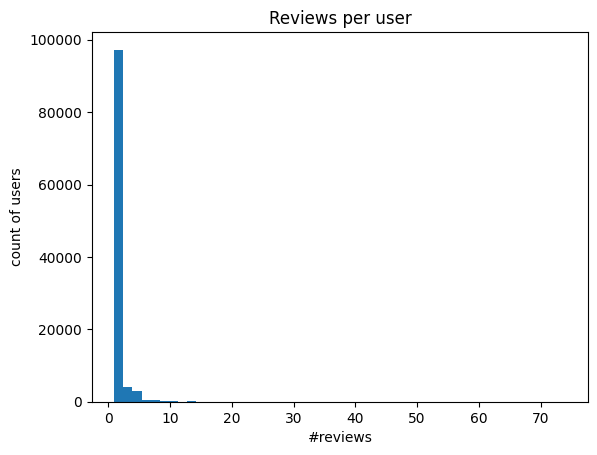

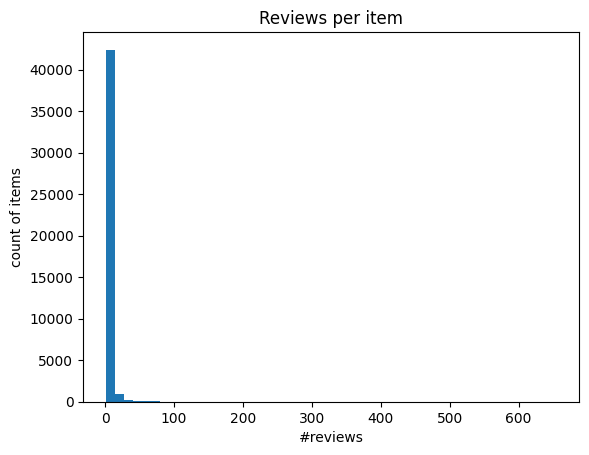

In [24]:
# =========================================================
# EDA 2 — Reviews per user / per item
# =========================================================
# Every user hasn't reviewed every item so there will be sparsity.
reviews_per_user = df.groupby("customer_id")["product_id"].count()
reviews_per_item = df.groupby("product_id")["customer_id"].count()

print("Users:", df["customer_id"].nunique())
print("Items:", df["product_id"].nunique())

print("\nReviews/user: mean =", reviews_per_user.mean(), "median =", reviews_per_user.median())
print("Reviews/item: mean =", reviews_per_item.mean(), "median =", reviews_per_item.median())
plt.figure()
plt.hist(reviews_per_user, bins=50)
plt.title("Reviews per user")
plt.xlabel("#reviews")
plt.ylabel("count of users")
plt.show()

plt.figure()
plt.hist(reviews_per_item, bins=50)
plt.title("Reviews per item")
plt.xlabel("#reviews")
plt.ylabel("count of items")
plt.show()

In [25]:
# =========================================================
# EDA 3 — Sparsity (density) estimate
# =========================================================
n_users = df["customer_id"].nunique()
n_items = df["product_id"].nunique()
n_obs = len(df)

density = n_obs / (n_users * n_items)
sparsity = 1 - density

print(f"Estimated density: {density:.8f}")
print(f"Estimated sparsity: {sparsity:.8f}")

Estimated density: 0.00003224
Estimated sparsity: 0.99996776


## Part 3 — Train / Validation / Test Split

**Task:** Split interactions into train/val/test.

**Option A (recommended):** **Per-user time-based holdout**
- Sort each user’s reviews by `review_date`.
- Put the last 1 review into **test**, the second-to-last into **validation**, the rest into **train**.

**Option B:** Random split with fixed seed (easier, but riskier for leakage realism).

**Requirements:**
- Ensure **most users** appear in train.
- When evaluating, compute item/user averages and profiles using **train only**.

**Deliverables:**
- `df_train`, `df_val`, `df_test`
- A short note explaining your split choice.

**Question:**
1. What “leakage” would happen if you compute averages from the full dataset instead of train?<br><br>
The mean would decrease from training set's 4.258657 average to the full dataset's 4.251056 average.


In [26]:
# =========================================================
# SPLIT: Per-user time-based holdout (recommended)
# =========================================================
df_sorted = df.sort_values(["customer_id", "review_date"]).reset_index(drop=True)

train_rows = []
val_rows = []
test_rows = []

for user_id, g in df_sorted.groupby("customer_id", sort=False):
    if len(g) < 3:
        # For very small histories, keep everything in train to reduce cold-start in eval
        train_rows.append(g)
        continue
    train_rows.append(g.iloc[:-2])
    val_rows.append(g.iloc[-2:-1])
    test_rows.append(g.iloc[-1:])

df_train = pd.concat(train_rows).reset_index(drop=True)
df_val = pd.concat(val_rows).reset_index(drop=True) if len(val_rows) else pd.DataFrame(columns=df.columns)
df_test = pd.concat(test_rows).reset_index(drop=True) if len(test_rows) else pd.DataFrame(columns=df.columns)

print("Train:", len(df_train), "Val:", len(df_val), "Test:", len(df_test))
display(df_train)
print("Unique users (train):", df_train["customer_id"].nunique())
print("Unique items (train):", df_train["product_id"].nunique())

Train: 132546 Val: 8721 Test: 8721


,customer_id,product_id,product_title,star_rating,review_date
0,10916,B00RA31B6C,4 Pack Music Book Clip or Page Holder,5,2015-05-09
1,10987,B000CZ0RLK,BEHRINGER C-1,5,2015-05-01
2,10987,B003OYLGWA,"Marshall Footswitch, One Button With LED",5,2015-05-01
3,11799,B00YU63MR8,Samsung S5 Case-Aurora 5D Bling Quicksand Tran...,5,2015-08-17
4,11861,B0002MJTZ8,"On Stage Round Base Microphone Stand, Black",5,2015-06-09
...,...,...,...,...,...
132541,53095826,B00ZU4G0ZK,TC Electronic PolyTune Clip,3,2015-08-20
132542,53095899,B003FO0LG6,iMBAPrice USB-MFAN USB Mini Desktop Fan,5,2015-07-22
132543,53095948,B0058MJX4O,Sony ECMCS3 Clip style Omnidirectional Stereo ...,1,2015-05-02
132544,53095971,B00MMLEIB2,Ricard Bunnel G2 Violin Outfit,5,2015-07-25


Unique users (train): 105963
Unique items (train): 40628


In [27]:
full_df = pd.read_csv(
    DATA_PATH,
    sep="\t",
    compression="gzip",
    usecols=USECOLS,
)

In [28]:
full_df.describe()

,customer_id,star_rating
count,9.040400e+05,904040.000000
mean,2.732993e+07,4.251056
std,1.551727e+07,1.216415
min,1.011300e+04,1.000000
25%,1.403699e+07,4.000000
50%,2.580910e+07,5.000000
75%,4.190775e+07,5.000000
max,5.309656e+07,5.000000


In [29]:
df_train.describe()

,customer_id,star_rating,review_date
count,1.325460e+05,132546.000000,132546
mean,2.442691e+07,4.258657,2015-06-14 16:01:05.836766
min,1.091600e+04,1.000000,2015-04-01 00:00:00
25%,1.113330e+07,4.000000,2015-05-06 00:00:00
50%,2.214991e+07,5.000000,2015-06-14 00:00:00
75%,3.957976e+07,5.000000,2015-07-23 00:00:00
max,5.309641e+07,5.000000,2015-08-31 00:00:00
std,1.646388e+07,1.243952,NaN


## Part 4 — Build Utility Data Structures (from TRAIN only)

You will build:
- `usersPerItem[item] = set(users who rated item)`
- `itemsPerUser[user] = set(items rated by user)`
- `ratingDict[(user,item)] = rating`
- `itemNames[item] = title`  (optional but helpful)
- `reviewsPerUser[user] = list of rows/dicts`
- `reviewsPerItem[item] = list of rows/dicts`
- `userAverages[user]`, `itemAverages[item]`, `globalMean`

**Deliverable:** Data structures populated from `df_train`.

**Question:**
1. If a user or item appears in val/test but not in train, what prediction should you return?<br><br>
Use the global base line. This is because we know the user's rating would be around the global consensus.

In [30]:
# =========================================================
# BUILD STRUCTURES FROM TRAIN
# =========================================================
usersPerItem = defaultdict(set)
itemsPerUser = defaultdict(set)
ratingDict = {}
itemNames = {}

reviewsPerUser = defaultdict(list)
reviewsPerItem = defaultdict(list)

# Iterate training set's rows, a list of NamedTuples, which  are basically a dictionary in tuple(immutable) form.
# row: (customer_id = cus_id, product_id = prod_id, star_rating = rating).
for row in df_train.itertuples(index=False):
    u = row.customer_id
    i = row.product_id
    r = int(row.star_rating)

    # Map items to their users, and vice versa.
    usersPerItem[i].add(u)
    itemsPerUser[u].add(i)
    # Map users and items to their rating.
    ratingDict[(u, i)] = r
    # Map item names to their id.
    itemNames[i] = row.product_title

    # store minimal record for prediction loops
    d = {"customer_id": u, "product_id": i, "star_rating": r}
    reviewsPerUser[u].append(d)
    reviewsPerItem[i].append(d)

globalMean = df_train["star_rating"].mean()

userAverages = {}
for u, items in itemsPerUser.items():
    rs = [ratingDict[(u, i)] for i in items]
    userAverages[u] = float(np.mean(rs))

itemAverages = {}
for i, users in usersPerItem.items():
    rs = [ratingDict[(u, i)] for u in users]
    itemAverages[i] = float(np.mean(rs))

globalMean

np.float64(4.258657371780363)

## Part 5 — Similarity Functions

**Required:** Implement **Jaccard similarity** for sets.

Optional (extra credit):
- Cosine similarity on sets (interaction-only)
- Cosine/Pearson on rating vectors (requires careful handling)

**Deliverables:**
- `jaccard(s1, s2)` (required)
- At least one additional similarity function (optional)

**Questions:**
1. When would Jaccard be a poor choice for similarity in rating prediction?<br><br>This is because Jaccard ignore the magnitude of the sets its given. Since these numerical rating i.e(1,2,3,4,5) instead binary(1=liked & 0=not liked) we don't consider how much a user like or disliked the item they're rating.<br><br>
2. If you use Pearson correlation, similarities can be negative. How should the denominator be handled?<br><br>
In cases of a negative similarity implies that the two element are not similar but actually opposite. The denominator can be 0, so we can say that there is no similar relationship between the two and return 0. 
<br><br>

In [31]:
def jaccard(s1: set, s2: set) -> float:
    """
    TODO: implement Jaccard similarity:
        |A ∩ B| / |A ∪ B|
    Return 0.0 if union is empty.
    """
    num = len(s1.intersection(s2)) 
    denom = len(s1.union(s2)) 
    return 0.0 if denom == 0 else num/denom


def cosine_set(s1: set, s2: set) -> float:
    """
    Optional: cosine similarity on *sets* (implicit feedback only).
    This is not cosine on rating vectors; it uses intersection size.
    """
    n1 = np.array(list(s1))
    n2 = np.array(list(s2))
    num = len(s1.intersection(s2)) 
    denom = np.sqrt(np.sum(n1**2))*  np.sqrt(np.sum(n2**2))
    return 0.0 if denom == 0 else num/denom

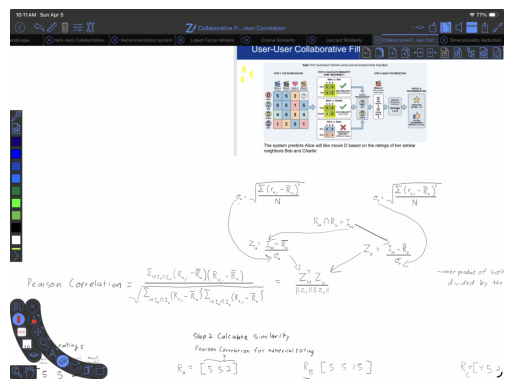

In [32]:
import matplotlib.image as mpimg
img = mpimg.imread("/home/anthony/Downloads/CollaborativeFilteringPearsonCorrelation.png")
plt.imshow(img)
plt.axis('off')
plt.show()

In [33]:
# Pearson Correlation is essentially the cosine similarity of z-scores intersecting elements.
def pearson_correlation(user1_ratings: dict, user2_ratings: dict) -> float:
    shared_movies = set(user1_ratings.keys()).intersection(set(user2_ratings.keys()))
    
    if not shared_movies:
         return 0.0
    
    n1 = np.array(list(user1_ratings.values()))
    n2 = np.array(list(user2_ratings.values()))
    
    intersect_1 = np.array(list([user1_ratings[movie] for movie in shared_movies]))
    intersect_2 = np.array(list([user2_ratings[movie] for movie in shared_movies]))

    mean_1 = np.mean(n1)
    mean_2 = np.mean(n2)

    std_dev_1 = np.std(n1)
    std_dev_2 = np.std(n2)

    # Zscores vectors
    z1 = (intersect_1 - mean_1) / std_dev_1
    z2 = (intersect_2 - mean_2) / std_dev_2

    # Pearson Correlation
    denom = (np.linalg.norm(z1) * np.linalg.norm(z2))
    if denom == 0:
         return 0
    return (z1 @ z2) / denom
    


## Part 6 — (Warm-up) Most Similar Items + Efficiency

**Task A (naive):** Implement `most_similar_naive(query_item, N)` by comparing the query item
to **every item** in `usersPerItem`.

**Task B (fast):** Implement `most_similar_fast(query_item, N)` by:
1. Collecting candidate items that were interacted with by users who also interacted with the query item.
2. Computing similarities only over those candidates.

**Deliverables:**
- Top-10 similar items for **one** query item (print item titles).
- A short note: Which component is slowest in the naive version and why?

**Question:**
1. Compare the computational complexity of naive vs. fast in words and/or Big-O terms.<br><br>
most_similar_naive: O(N^2)
most_similar_fast: O(users^2)
Unlike the naive function the fast only calculate the users that have rated the query item rather than all the users in dataset. This is much better improvement since dataset in production can contain millions of users.
<br><br>


In [34]:
# O(N^2)
def most_similar_naive(query_item: str, N: int = 10):
    """
    TODO:
    - For each item i2 in usersPerItem:
        compute sim(query_item, i2)
    - Return sorted list of (sim, item_id)
    """
    similarities = []
    for i2 in usersPerItem:
        if query_item == i2: continue
        sim = jaccard(usersPerItem[query_item],usersPerItem[i2])
        similarities.append((sim,i2))
    similarities.sort(reverse=True)
    return similarities[:N]


# O(users^2)
def most_similar_fast(query_item: str, N: int = 10):
    """
    TODO:
    - Candidate items are union of itemsPerUser[u] for u in usersPerItem[query_item]
    - Compute similarity only on candidate items
    """
    similarities = []

    candidates = set()
    for user in usersPerItem[query_item]:
        candidates.update(itemsPerUser[user])
    for i2 in candidates:
        if query_item == i2: continue
        sim = jaccard(usersPerItem[query_item],usersPerItem[i2])
        similarities.append((sim,i2))
    similarities.sort(reverse=True)

    return similarities[:N]

# TODO: pick a query item that exists in train
# hint: query_item = df_train.iloc[0]["product_id"]
most_similar_fast(df_train.iloc[0]["product_id"])

[]

## Part 7 — Evaluation Utilities + Baselines

**Task:** Implement evaluation metrics and at least 2 baselines.

**Required metric:**
- MSE or RMSE (choose one as your main metric; you may report both)

**Required baseline:**
1. Global mean: always predict `globalMean`

**Pick at least one more baseline:**
- Item mean baseline: predict `itemAverages[item]` else global mean
- User mean baseline: predict `userAverages[user]` else global mean
- (Optional) user+item bias baseline: `globalMean + b_u + b_i` (extra credit)

**Deliverables:**
- `evaluate(df_split, predictor_fn)` returning metric(s)
- Baseline results on **val** and/or **test**

**Question:**
1. Which baseline is strongest here and why (based on your EDA)?<br><br>
The global baseline is the strongest because its has the lowest RMSE of 1.034.

In [35]:
def mse(y_true, y_pred) -> float:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.mean((y_true - y_pred) ** 2))

def rmse(y_true, y_pred) -> float:
    return float(np.sqrt(mse(y_true, y_pred)))

def mae(y_true, y_pred) -> float:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.mean(np.abs(y_true - y_pred)))


def predict_global_mean(u, i) -> float:
    return float(globalMean)

def predict_item_mean(u, i) -> float:
    return float(itemAverages.get(i, globalMean))

def predict_user_mean(u, i) -> float:
    return float(userAverages.get(u, globalMean))


def evaluate(df_split: pd.DataFrame, predict_fn):
    y_true = df_split["star_rating"].astype(int).tolist()
    y_pred = [predict_fn(u, i) for u, i in zip(df_split["customer_id"], df_split["product_id"])]
    return {
        "mse": mse(y_true, y_pred),
        "rmse": rmse(y_true, y_pred),
        "mae": mae(y_true, y_pred),
    }

print("Global mean baseline (val):", evaluate(df_val, predict_global_mean))
print("Item mean baseline   (val):", evaluate(df_val, predict_item_mean))
print("User mean baseline   (val):", evaluate(df_val, predict_user_mean))

Global mean baseline (val): {'mse': 1.0707805176104652, 'rmse': 1.0347852519293388, 'mae': 0.8412739455587409}
Item mean baseline   (val): {'mse': 1.216272535744108, 'rmse': 1.1028474671250363, 'mae': 0.785605322674501}
User mean baseline   (val): {'mse': 1.372260837439203, 'rmse': 1.1714353748454085, 'mae': 0.6569959845790043}


# Exercise 1 — Normalized Item-Based Collaborative Filtering (Required)

In this exercise, you will implement a **normalized item-based collaborative filtering** model.

Instead of directly using a user’s raw ratings, you will:
- Look at items the user has rated
- Compute similarity between the target item and those items
- Normalize neighbor ratings by subtracting the neighbor item’s average
- Take a weighted average
- Add back the target item's average

Use **Jaccard similarity over user sets**.

---

## What You Must Implement

- Item–item similarity with caching
- Top-K neighbors (recommended K = 20)
- Normalized rating prediction
- Proper cold-start handling:
  - Unknown user
  - Unknown item
  - No similar neighbors

Use **train data only** when computing averages and similarities.

---

## Deliverables

1. Implement:
   ```python
   predict_item_cf_normalized(user, item, K=20)

In [ ]:
# =========================================================
# EXERCISE 1: Normalized Item-based CF
# =========================================================
item_item_sim_cache = {}

def item_item_similarity(i1: str, i2: str) -> float:
    """
    TODO:
    - Use a cache key that is order-invariant: (min(i1,i2), max(i1,i2))
    - Similarity: jaccard(usersPerItem[i1], usersPerItem[i2])
    """
    # TODO
    i1_users = usersPerItem[i1]
    i2_users = usersPerItem[i2]
    if (min(i1,i2),max(i1,i2)) in item_item_sim_cache:
        return item_item_sim_cache[(min(i1,i2),max(i1,i2))]
    sim = jaccard(i1_users,i2_users)
    item_item_sim_cache[(min(i1,i2),max(i1,i2))]= sim
    return sim

def most_similar_items_fast(query_item: str, N: int = 10):
    """
    TODO:
    - Candidate items are union of itemsPerUser[u] for u in usersPerItem[query_item]
    - Compute similarity only on candidate items
    """
    similarities = []

    candidates = set()
    for user in usersPerItem[query_item]:
        candidates.update(itemsPerUser[user])
    for i2 in candidates:
        if query_item == i2: continue
        sim = item_item_similarity(query_item,i2)
        similarities.append((sim,i2))
    similarities.sort(reverse=True)

    return similarities[:N]
    
def predict_item_cf_normalized(user: str, item: str, K: int = 20) -> float:
    """
    TODO:
    Implement normalized item-based CF prediction.

    Tips:
    - Neighbor candidates are items user rated in train: itemsPerUser[user]
    - For each neighbor j:
        sim = sim(item, j)
        contribution = sim * (r(u,j) - itemAverages[j])
    - Use only sim > 0
    - Optionally keep only top-K neighbors by sim
    - Final:
        itemAverages[item] + sum(contrib)/sum(sim)

    Must handle cold start safely.
    """
    # Get top K neighbors
    topSimPairs = [(sim,i) for (sim,i) in most_similar_items_fast(item,N=K) if (user,i) in ratingDict and sim > 0]
    if not topSimPairs:
        if item not in itemAverages:
            # New item means it unrated by users: return global average.
            return globalMean
        elif user not in userAverages:
            # New user cold start on existing item: return item's average rating.
            return itemAverages[item]
        else:
            # No similarities return item baseline.
            target_bias = itemAverages[item] - globalMean
            user_bias = userAverages[user] - globalMean
            return globalMean + user_bias + target_bias
    
    topItemSimilarities, topSimilarItems = zip(*topSimPairs)
    topItemSimilarities = np.array(list(topItemSimilarities))
    topSimilarItemAverages = np.array([itemAverages[item] for item in topSimilarItems])
    topSimilarItemRatings = np.array([ratingDict[(user,item)] for item in topSimilarItems])

    # Calculate biases.
    target_bias = itemAverages[item] - globalMean
    user_bias = userAverages[user] - globalMean
    item_bias = topSimilarItemAverages - globalMean
    
    # Calculate item baseline b and target baseline b_xi.
    b = globalMean + user_bias + item_bias
    b_xi = globalMean + user_bias + target_bias
    return b_xi + (topItemSimilarities.T @ (topSimilarItemRatings - b))/np.sum(np.abs(topItemSimilarities))
    

def predict_item_cf(user: str, item: str, K: int = 20) -> float:
    topSimPairs = [(sim,i) for (sim,i) in most_similar_items_fast(item,N=K) if (user,i) in ratingDict and sim > 0]
    if not topSimPairs:
        return globalMean
    topItemSimilarities, topSimilarItems = zip(*topSimPairs)
    topItemSimilarities = np.array(list(topItemSimilarities))
    topSimilarItemRatings = np.array([ratingDict[(user,item)] for item in topSimilarItems])
    return (topItemSimilarities.T @ (topSimilarItemRatings))/np.sum(np.abs(topItemSimilarities))

# TODO: evaluate
print("Exercise 1 (val):", evaluate(df_val, lambda u,i: predict_item_cf_normalized(u,i,K=20)))
print("Exercise 1 (val):", evaluate(df_val, lambda u,i: predict_item_cf(u,i,K=20)))

Exercise 1 (val): {'mse': 1.5569488183822349, 'rmse': 1.2477775516422127, 'mae': 0.8949222499929474}
Exercise 1 (val): {'mse': 1.0770049267526633, 'rmse': 1.0377884788109104, 'mae': 0.827988531142857}


# Exercise 2 — User-Based Collaborative Filtering (Required)

In this exercise, you will implement **user-based collaborative filtering**.

Instead of comparing items, you will:
- Find users who rated the target item
- Compute similarity between users
- Use a weighted average of their ratings

Use **Jaccard similarity over item sets**.

---

## What You Must Implement

- User–user similarity with caching
- Top-K neighbor users (recommended K = 20)
- Weighted average prediction
- Proper cold-start handling:
  - Unknown user
  - Unknown item
  - No similar users

Use **train data only** for similarity and averages.

---

## Deliverables

1. Implement:
   ```python
   predict_user_cf(user, item, K=20)

In [37]:
# =========================================================
# EXERCISE 2: User-based CF
# =========================================================
user_user_sim_cache = {}

def user_user_similarity(u1: str, u2: str) -> float:
    """
    TODO:
    - order-invariant cache key: (min(u1,u2), max(u1,u2))
    - similarity: jaccard(itemsP()
erUser[u1], itemsPerUser[u2])
    """
    # TODO
    u1_items = itemsPerUser[u1]
    u2_items = itemsPerUser[u2]
    
    if (min(u1,u2),max(u1,u2)) in user_user_sim_cache:
        return user_user_sim_cache[(min(u1,u2),max(u1,u2))]
    
    sim = jaccard(u1_items,u2_items)
    
    user_user_sim_cache[(min(u1,u2),max(u1,u2))] = sim
    return sim

def most_similar_users_fast(query_user: str, N: int = 10):
    """
    TODO:
    - Candidate items are union of itemsPerUser[u] for u in usersPerItem[query_item]
    - Compute similarity only on candidate items
    """
    similarities = []

    candidates = set()
    for item in itemsPerUser[query_user]:
        candidates.update(usersPerItem[item])
    
    for u2 in candidates:
        if query_user == u2: continue
        sim = user_user_similarity(query_user,u2)
        similarities.append((sim,u2))
    similarities.sort(reverse=True)

    return similarities[:N]


def predict_user_cf(user: str, item: str, K: int = 20) -> float:
    """
    TODO:
    - Neighbor candidates: users who rated item in train: usersPerItem[item]
      (or reviewsPerItem[item] if you prefer iterating rows)
    - For each neighbor v:
        sim = sim(user, v)
        contribution = sim * r(v, item)
    - Use sim > 0
    - Optionally keep top-K by sim
    - Return sum(contrib)/sum(sim)

    Must handle cold start.
    """
    topSimPairs =  [(sim,u) for sim,u in most_similar_users_fast(user,N=K) if (user,u) in ratingDict and sim > 0]
    if not topSimPairs:
        if item not in itemAverages:
            # New item means it unrated by users: return global average.
            return globalMean
        elif user not in userAverages:
            # New user cold start on existing item: return item's average rating.
            return itemAverages[item]
        else:
            # No similarities return item baseline.
            target_bias = itemAverages[item] - globalMean
            user_bias = userAverages[user] - globalMean
            return globalMean + user_bias + target_bias
    
    topUserSimilarities, topSimilarUsers = zip(*topSimPairs)
    topUserSimilarities = np.array(list(topUserSimilarities))
    topSimilarUserAverages = np.array([userAverages[neighbor_u] for neighbor_u in topSimilarUsers])
    topSimilarUserRatings = np.array([ratingDict[(meighbor_u,item)] for meighbor_u in topSimilarUsers])

    # Calculate biases.
    target_bias = itemAverages[item] - globalMean
    user_bias = userAverages[user] - globalMean
    item_bias = topSimilarUserAverages - globalMean
    
    # Calculate item baseline b and target baseline b_xi.
    b = globalMean + user_bias + item_bias
    b_xi = globalMean + user_bias + target_bias
    return b_xi + (topUserSimilarities.T @ (topSimilarUserRatings - b))/np.sum(np.abs(topUserSimilarities))
    

# TODO: evaluate
print("Exercise 2 (val):", evaluate(df_val, lambda u,i: predict_user_cf(u,i,K=20)))

Exercise 2 (val): {'mse': 1.5539095339235767, 'rmse': 1.2465590775906197, 'mae': 0.8947174976604648}


## Part 8 — Results Table + Model Comparison (required)

Create a small results table (validation and/or test) like:

- Global mean baseline
- Item mean baseline (or user mean baseline)
- Exercise 1 (normalized item-based CF)
- Exercise 2 (user-based CF)

Report at least **RMSE** (or MSE) and **MAE**.

Then answer:

1. Which method is best by your main metric?<br><br>Prior to implementing regular item-item the user-user CF was the better metric with an RMSE 1.246 oppose to item-item-CF-Norm's 1.247 RMSE. After making hte item-item without normalization it became the superior metric with a RMSE of 1.035<br><br>
2. Does the “best” method change if you care about runtime?<br><br>The best method does change. The user-user approach will be fall behind the item-item due to the users' taste changing repeatedly where items stay consistent.<br><br>
3. Identify 2 common failure modes (e.g., cold-start users/items, popularity bias).<br><br>The first common failure is the cold start for users and items, new users or items will need to be given global mean for the items when it comes to rating an item. The popularity bias is also issue because the dataset is filled with 5's more than any other rating which can cause a serious bias in what the global mean used for rating in the presence of new users and items. Preprocessing the data to even the the number occurrences will be necessary to remedy this.<br><br>

*(Tip: include 1–2 sentences referencing your EDA findings.)*

In [38]:
# TODO: Fill this table after you implement predictors.
# Suggested approach: compute metrics on df_val (and df_test) and print nicely.

results = []

def add_result(name, fn):
    m = evaluate(df_val, fn)
    results.append({"model": name, **m})

add_result("GlobalMean", predict_global_mean)
add_result("ItemMean", predict_item_mean)
add_result("UserMean", predict_user_mean)

# TODO: uncomment once implemented
add_result("Ex1_ItemCF_Norm_K20", lambda u,i: predict_item_cf_normalized(u,i,K=20))
add_result("Ex2_UserCF_K20", lambda u,i: predict_user_cf(u,i,K=20))
add_result("Ex1_ItemCF_K20", lambda u,i: predict_item_cf(u,i,K=20))

pd.DataFrame(results).sort_values("rmse")

,model,mse,rmse,mae
0,GlobalMean,1.070781,1.034785,0.841274
5,Ex1_ItemCF_K20,1.077005,1.037788,0.827989
1,ItemMean,1.216273,1.102847,0.785605
2,UserMean,1.372261,1.171435,0.656996
4,Ex2_UserCF_K20,1.553910,1.246559,0.894717
3,Ex1_ItemCF_Norm_K20,1.556949,1.247778,0.894922


## Part 9 — Short Answer / Reflection (required)

Answer in 2–6 sentences each.

1. **Efficiency:** What was the slowest computation in your pipeline? What specific optimization helped most?<br><br>
The slowest computation in the pipeline was finding the top k similar neighbors since it would require calling the jaccard function repeatedly running through the shared neighbor each time we want to find single neighbor resulting in O(N^2), but after creating a cache we could cut some jaccard calculations.<br><br>

2. **Similarity choice:** Why is Jaccard reasonable for implicit-style similarity here, and what information does it ignore?<br><br>
Jaccard is reasonable because users interaction can result in rate or not rate for an item here. What Jaccard does miss is magnitude or how strong the user's rating is.
<br><br>
3. **Normalization:** Compare item-based predictions with and without normalization. What changed and why?<br><br>
The item-based prediction is better without normalization. The RMSE 1.037788 opposed to 1.247778, this likely because of the current sparsity of the data is more than what the normalization method can handle.
<br><br>
4. **Bias and fairness:** Identify one potential bias in this dataset and one mitigation strategy (even if you did not implement it).<br><br>
There is inflationary bias in the dataset due to all the 5's users are rating for items. We can mitigate the issue with preprocessing to modify the data to reduce the number of 5's throughout the dataset to a more balanced dataset.
<br><br>
5. **Generalization:** If you switch from predicting ratings to generating **Top-N recommendations**, what evaluation metric(s) would you use and why?<br><br>
A use can mark eac recommendation as good or bad, then you could find the tradeoff curve between false-positive. Additionally with the user like history you can be able to find false-negatives based on the similarity between the item in the users history and other items that the model did not recommend. This is Receiver Operating Character (ROC) curve
<br><br>

---

## Extra credit ideas (optional)
- Implement a user-user **Pearson** similarity (requires mean-centering) and compare.

In [39]:
user_user_sim_cache_2 = {}

# Pearson Correlation is essentially the cosine similarity of z-scores intersecting elements.
def pearson_correlation(user1_ratings: dict, user2_ratings: dict) -> float:
    shared_movies = set(user1_ratings.keys()).intersection(set(user2_ratings.keys()))
    
    if not shared_movies:
         return 0.0
    
    n1 = np.array(list(user1_ratings.values()))
    n2 = np.array(list(user2_ratings.values()))
    
    intersect_1 = np.array(list([user1_ratings[movie] for movie in shared_movies]))
    intersect_2 = np.array(list([user2_ratings[movie] for movie in shared_movies]))

    mean_1 = np.mean(n1)
    mean_2 = np.mean(n2)

    std_dev_1 = np.std(n1)
    std_dev_2 = np.std(n2)

    # Zscores vectors
    z1 = (intersect_1 - mean_1) / std_dev_1
    z2 = (intersect_2 - mean_2) / std_dev_2

    # Pearson Correlation
    denom = (np.linalg.norm(z1) * np.linalg.norm(z2))
    if denom == 0:
         return 0
    return (z1 @ z2) / denom
    

def user_user_similarity_2(u1: str, u2: str) -> float:
    """
    TODO:
    - order-invariant cache key: (min(u1,u2), max(u1,u2))
    - similarity: jaccard(itemsP()
erUser[u1], itemsPerUser[u2])
    """
    # TODO
    
    u1_ratings = {item : ratingDict[(u1,item)]  for item in itemsPerUser[u1]}
    u2_ratings = {item : ratingDict[(u2,item)]  for item in itemsPerUser[u2]}
    
    if (min(u1,u2),max(u1,u2)) in user_user_sim_cache:
        return user_user_sim_cache[(min(u1,u2),max(u1,u2))]
    
    sim = pearson_correlation(u1_ratings,u2_ratings)
    
    user_user_sim_cache[(min(u1,u2),max(u1,u2))] = sim
    return sim

def most_similar_users_fast_2(query_user: str, N: int = 10):
    """
    TODO:
    - Candidate items are union of itemsPerUser[u] for u in usersPerItem[query_item]
    - Compute similarity only on candidate items
    """
    similarities = []

    candidates = set()
    for item in itemsPerUser[query_user]:
        candidates.update(usersPerItem[item])
    
    for u2 in candidates:
        if query_user == u2: continue
        sim = user_user_similarity_2(query_user,u2)
        similarities.append((sim,u2))
    similarities.sort(reverse=True)

    return similarities[:N]


def predict_user_cf_2(user: str, item: str, K: int = 20) -> float:
    """
    TODO:
    - Neighbor candidates: users who rated item in train: usersPerItem[item]
      (or reviewsPerItem[item] if you prefer iterating rows)
    - For each neighbor v:
        sim = sim(user, v)
        contribution = sim * r(v, item)
    - Use sim > 0
    - Optionally keep top-K by sim
    - Return sum(contrib)/sum(sim)

    Must handle cold start.
    """
    topSimPairs =  [(sim,u) for sim,u in most_similar_users_fast_2(user,N=K) if (user,u) in ratingDict and sim > 0]
    if not topSimPairs:
        if item not in itemAverages:
            # New item means it unrated by users: return global average.
            return globalMean
        elif user not in userAverages:
            # New user cold start on existing item: return item's average rating.
            return itemAverages[item]
        else:
            # No similarities return item baseline.
            target_bias = itemAverages[item] - globalMean
            user_bias = userAverages[user] - globalMean
            return globalMean + user_bias + target_bias
    
    topUserSimilarities, topSimilarUsers = zip(*topSimPairs)
    topUserSimilarities = np.array(list(topUserSimilarities))
    topSimilarUserAverages = np.array([userAverages[neighbor_u] for neighbor_u in topSimilarUsers])
    topSimilarUserRatings = np.array([ratingDict[(meighbor_u,item)] for meighbor_u in topSimilarUsers])

    # Calculate biases.
    target_bias = itemAverages[item] - globalMean
    user_bias = userAverages[user] - globalMean
    item_bias = topSimilarUserAverages - globalMean
    
    # Calculate item baseline b and target baseline b_xi.
    b = globalMean + user_bias + item_bias
    b_xi = globalMean + user_bias + target_bias
    return b_xi + (topUserSimilarities.T @ (topSimilarUserRatings - b))/np.sum(np.abs(topUserSimilarities))
    

In [41]:
# TODO: Fill this table after you implement predictors.
# Suggested approach: compute metrics on df_val (and df_test) and print nicely.

results = []

def add_result(name, fn):
    m = evaluate(df_val, fn)
    results.append({"model": name, **m})

add_result("GlobalMean", predict_global_mean)
add_result("ItemMean", predict_item_mean)
add_result("UserMean", predict_user_mean)

# TODO: uncomment once implemented
add_result("Ex1_ItemCF_Norm_K20", lambda u,i: predict_item_cf_normalized(u,i,K=20))
add_result("Ex2_UserCF_K20", lambda u,i: predict_user_cf(u,i,K=20))
add_result("Ex2_UserCF2_K20", lambda u,i: predict_user_cf_2(u,i,K=20))
add_result("Ex1_ItemCF_K20", lambda u,i: predict_item_cf(u,i,K=20))

pd.DataFrame(results).sort_values("rmse")

,model,mse,rmse,mae
0,GlobalMean,1.070781,1.034785,0.841274
6,Ex1_ItemCF_K20,1.077005,1.037788,0.827989
1,ItemMean,1.216273,1.102847,0.785605
2,UserMean,1.372261,1.171435,0.656996
5,Ex2_UserCF2_K20,1.553910,1.246559,0.894717
4,Ex2_UserCF_K20,1.553910,1.246559,0.894717
3,Ex1_ItemCF_Norm_K20,1.556949,1.247778,0.894922
